# 🧠 LangGraph in Production — Days 1–5 Code-Along

**Sprint:** 14-Day AI Engineer Skills Sprint  
**Topic:** LangGraph — from mental model to deployed multi-agent system  
**Pace:** ~2 hrs/day | Style: short concept read → heavy hands-on  

---

## How to use this notebook

- Each day has a **Concepts** section — read it even on the laziest day. It has the key mental models.  
- Each day has **📖 Must-Read Docs** — links to the exact LangGraph doc sections that matter. Skim these before coding.  
- Each day has **🧪 Try It Yourself** cells — attempt these yourself first. Leave them blank and try from scratch.  
- Each day has **✅ Reference Solution** cells — fall back to these if you're stuck or short on time. They are complete, working code.  
- Day 5 is deployment — the notebook covers the FastAPI + Docker code. The EC2 steps are in the markdown instruction cells.

---

## Environment

- Python 3.10+  
- OpenAI API key (or swap for Bedrock/Anthropic — adapters shown in Day 1)  
- AWS CLI configured with a profile (needed for Day 5)


In [ ]:
# ── SETUP: Install dependencies ──────────────────────────────────────────────
# Run this once. If you already have these, just verify versions.

# !pip install -U langgraph langchain-openai langchain-community python-dotenv

import os
from dotenv import load_dotenv

load_dotenv()  # expects OPENAI_API_KEY in a .env file at project root

# Quick sanity check
import langgraph, langchain_openai
print(f"langgraph   : {langgraph.__version__}")
print(f"langchain-openai: {langchain_openai.__version__}")
print("OPENAI_API_KEY set:", bool(os.getenv("OPENAI_API_KEY")))


---
# 📅 Day 1 — Mental Model: What is LangGraph and why does it exist?

**Time budget:** ~30 min concepts + 90 min hands-on

---

## 📖 Must-Read Docs (do these even on the laziest day)

| Doc | What you'll learn | URL |
|---|---|---|
| Why LangGraph? | The core argument vs chains | https://langchain-ai.github.io/langgraph/concepts/why-langgraph/ |
| LangGraph Quickstart | StateGraph, nodes, edges, compile | https://langchain-ai.github.io/langgraph/tutorials/introduction/ |
| Low-Level Concepts | State, reducers, nodes in depth | https://langchain-ai.github.io/langgraph/concepts/low_level/ |

**Minimum read on a lazy day:** Read the "Why LangGraph?" page. 5 minutes. It re-wires how you think about agents.

---

## 🧠 Core Concepts (read before coding)

### The problem with chains

LangChain chains are **directed acyclic graphs (DAGs)** — A→B→C, no loops, no branching back.  
Real agents need:
- **Cycles** — call a tool, check result, maybe call another tool, repeat
- **Shared state** — all nodes read+write the same data structure, no manual passing
- **Conditional routing** — the LLM itself decides what runs next

### LangGraph primitives

```
StateGraph    → the container for your whole workflow
State         → a TypedDict — the single source of truth flowing through the graph
Node          → a Python function: takes state, returns partial state update
Edge          → a fixed connection between two nodes (A always goes to B)
Conditional Edge → a function decides which node to go to next
compile()     → "freezes" the graph into a runnable CompiledGraph
invoke()      → run the graph synchronously, return final state
stream()      → run the graph, yield state after each node finishes
```

### The state object — why it matters

Think of state as a **shared whiteboard** every node can read and write.  
- Defined as a `TypedDict` (or you can use `dataclass`)  
- Each node returns a **dict with only the fields it changed** — LangGraph merges the update  
- Special field type: `Annotated[list, add_messages]` — auto-appends instead of overwriting

### Compile → invoke flow

```
graph_def = StateGraph(MyState)
graph_def.add_node("node_a", fn_a)
graph_def.add_node("node_b", fn_b)
graph_def.add_edge("node_a", "node_b")
graph_def.set_entry_point("node_a")
graph_def.set_finish_point("node_b")

app = graph_def.compile()      # locked and loaded
result = app.invoke({"field": "value"})   # run it
```


### 🧪 Try It Yourself — 1.1: Define the State

Define a `TypedDict` called `BasicState` with at least 3 fields:
- `query` — the user's input string  
- `response` — the LLM's answer string  
- `step_log` — a list of strings (you'll append to this at each node)  

Then instantiate it as a dict and print it to confirm the structure.

In [3]:
# 🧪 YOUR CODE HERE — Day 1.1: Define BasicState
# Goal: TypedDict with query (str), response (str), step_log (list[str])

from typing import TypedDict

class BasicState:
    query : str
    response : str
    step_log : list[str]

test1: BasicState = {
    "query" : "Hello",
    "response" : "Hi",
    "step_log" : ["responded"]
}

print(test1)
print("Fields:", list(BasicState.__annotations__.keys()))

{'query': 'Hello', 'response': 'Hi', 'step_log': ['responded']}
Fields: ['query', 'response', 'step_log']


In [ ]:
# ✅ REFERENCE SOLUTION — Day 1.1: Define BasicState
# ─────────────────────────────────────────────────────────────────────────────
# KEY INSIGHT: TypedDict gives you type hints without overhead.
# list[str] for step_log means you'll append strings — don't overwrite the list.
# When a node returns {"step_log": ["new entry"]}, LangGraph will REPLACE the list
# unless you use a reducer. We keep it simple on Day 1 — Day 4 shows reducers.

from typing import TypedDict

class BasicState(TypedDict):
    query: str            # user's input — set once at entry point
    response: str         # LLM's final answer — written by the last node
    step_log: list[str]   # running log of what each node did

# Sanity check — create a sample state
sample_state: BasicState = {
    "query": "What is the capital of Australia?",
    "response": "",
    "step_log": []
}
print(sample_state)
print("Fields:", list(BasicState.__annotations__.keys()))


### 🧪 Try It Yourself — 1.2: Write Two Nodes

Write two node functions that operate on `BasicState`:

1. **`call_llm(state)`** — calls an LLM with `state["query"]`, stores the response in `state["response"]`, appends `"call_llm: done"` to `step_log`. Returns a partial state dict.
2. **`format_output(state)`** — wraps the response in a nice string like `"Answer: {response}"`, appends `"format_output: done"` to `step_log`. Returns the updated fields.

**Rule for nodes:** Always return a `dict` with only the fields you changed — not the whole state.

In [ ]:
# ✅ REFERENCE SOLUTION — Day 1.2: Nodes
# ─────────────────────────────────────────────────────────────────────────────
# KEY INSIGHTS:
# 1. Nodes receive the FULL current state — read anything you need.
# 2. Nodes return ONLY the fields they changed — LangGraph shallow-merges the dict.
# 3. For list fields, you need to handle appending manually here (no reducer set up yet).
#    We read the existing list, append, and return the whole updated list.

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def call_llm(state: BasicState) -> dict:
    """Node 1: Send the query to the LLM, capture the response."""
    messages = [HumanMessage(content=state["query"])]
    ai_response = llm.invoke(messages)

    return {
        "response": ai_response.content,
        "step_log": state["step_log"] + ["call_llm: received response from LLM"],
    }


def format_output(state: BasicState) -> dict:
    """Node 2: Wrap the raw LLM response in a clean format."""
    formatted = f"Answer: {state['response']}"

    return {
        "response": formatted,
        "step_log": state["step_log"] + ["format_output: wrapped response"],
    }


# Quick test of each node in isolation (no graph yet)
test_state: BasicState = {"query": "What is 2 + 2?", "response": "", "step_log": []}
after_llm = call_llm(test_state)
print("After call_llm:", after_llm)

merged = {**test_state, **after_llm}
after_format = format_output(merged)
print("After format_output:", after_format)


In [12]:
# 🧪 YOUR CODE HERE — Day 1.2: Write call_llm and format_output nodes
# from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Write call_llm(state: BasicState) -> dict:
# Write format_output(state: BasicState) -> dict:

from langgraph.graph import StateGraph, START, END

from typing import TypedDict

class BasicState(TypedDict):
    query: str            # user's input — set once at entry point
    response: str         # LLM's final answer — written by the last node
    step_log: list[str]   # running log of what each node did


def mock_llm(state: BasicState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}


def call_llm(state: BasicState):
    result = mock_llm(state)
    # state["response"] = result
    # state["step_log"].append("call_llm:done")
    return {"response" : result, 
            "step_log": state["step_log"] + ["call_llm:done"]}

def format_output(state: BasicState):
    # state["response"] = f'Answer: {state["response"]["content"]}'
    # state["step_log"].append("format_output:done")
    return {"response" : f'Answer: {state["response"]["messages"][0]["content"]}', 
            "step_log": state["step_log"] + ["format_output:done"]}

builder = StateGraph(BasicState)
builder.add_node("call_llm", call_llm)
builder.add_node("format_output", format_output)
builder.add_edge(START, "call_llm")
builder.add_edge("call_llm", "format_output")
builder.add_edge("call_llm", END)

graph = builder.compile()

initial_state: BasicState = {
    "query" : "Hello ?", 
    "response" : "", 
    "step_log" : []
}
output = graph.invoke(initial_state)

print(output)

    


{'query': 'Hello ?', 'response': 'Answer: hello world', 'step_log': ['call_llm:done', 'format_output:done']}


### Local LLM setup

In [49]:
!printenv

OSLogRateLimit=64
MallocNanoZone=0
__CFBundleIdentifier=com.microsoft.VSCode
COMMAND_MODE=unix2003
PATH=/Users/s748779/CEP_AI/anzsic_mapping/.venv/bin:/Users/s748779/.rd/bin:/Users/s748779/gemini_local/google-cloud-sdk/bin:/opt/homebrew/opt/node@22/bin:/opt/homebrew/opt/node@22/bin:/Users/s748779/Library/Application Support/Code/User/globalStorage/github.copilot-chat/debugCommand:/Users/s748779/Library/Application Support/Code/User/globalStorage/github.copilot-chat/copilotCli:/opt/homebrew/bin:/opt/homebrew/sbin:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/opt/pmk/env/global/bin:/Users/s748779/Library/Application Support/Code/User/globalStorage/github.copilot-chat/debugCommand:/Users/s748779/Library/Application Support/Code/User/global

In [50]:
!gcloud auth login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=32555940559.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fappengine.admin+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcompute+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.reauth&state=yQoKMhkvBwfHtZScmvqKmSaF62ocJL&access_type=offline&code_challenge=95Y_2SNwLp0T18eeFIt7tOXjfjYV66ujs6CwmR33u9E&code_challenge_method=S256


You are now logged in as [vikesh.morye@iag.com.au].
Your current project is [top-arc-65ca].  You can change this setting by running:
  $ gcloud config set project PROJECT_ID


In [65]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=TWG92uz2JczuYjSgCgaGmo9Rgm38yg&access_type=offline&code_challenge=YuAQXfB1wZertK4tEAav7v9C6BI_SGG-fsJIvXK3w5M&code_challenge_method=S256


Credentials saved to file: [/Users/s748779/.config/gcloud/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "top-arc-65ca" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning the resource.


I0000 00:00:1772586242.759107 15573494 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: self signed certificate in certificate chain
I0000 00:00:1772586252.769315 15573493 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: self signed certificate in certificate chain
I0000 00:00:1772586252.769292 15573489 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: self signed certificate in certificate chain
I0000 00:00:1772586252.769287 15573492 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: self signed certificate in certificate chain
I0000 00:00:1772586252.769338 15573490 ssl_transport_security.cc:1884] Hands

In [69]:
# model locally initialised
# ── Add the prod project root to sys.path ─────────────────────────────────────
PROD_ROOT = "/Users/s748779/CEP_AI/anzsic_mapping_v1"
if PROD_ROOT not in sys.path:
    sys.path.insert(0, PROD_ROOT)

print(f"sys.path includes: {PROD_ROOT}")
from prod.adapters.gcp_auth import GCPAuthManager
from prod.adapters.gemini_llm import GeminiLLMAdapter
from prod.config.settings import get_settings

settings = get_settings()
auth     = GCPAuthManager(settings)
llm      = GeminiLLMAdapter(auth, settings) # model initialised here as llm

# print(f"Model      : {llm.model_name}")
print(f"Project    : {settings.gcp_project_id}")
print(f"Location   : {settings.gcp_location_id}")
print(f"Proxy      : {settings.https_proxy or '(none)'}")
print(f"LLM timeout: {settings.llm_timeout}s")

sys.path includes: /Users/s748779/CEP_AI/anzsic_mapping_v1
Project    : top-arc-65ca
Location   : australia-southeast1
Proxy      : cloudproxy.auiag.corp:8080
LLM timeout: 90s


I0000 00:00:1772586287.794046 15573489 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: self signed certificate in certificate chain


In [68]:
# Fetch a token — will raise AuthenticationError if gcloud is not authed
token = auth.get_token()
print(f"✅ Token obtained — first 20 chars: {token[:20]}...")

✅ Token obtained — first 20 chars: ya29.a0ATkoCc67FOui6...


I0000 00:00:1772586277.789302 15573487 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: self signed certificate in certificate chain


In [19]:
# model quick testing
import json

_SYSTEM_PROMPT = (
    "You are an ANZSIC classification assistant. "
    "Return a JSON array of objects with fields: rank, anzsic_code, anzsic_desc, reason."
)

_USER_PROMPT = (
    'Classify the occupation "mobile mechanic" into ANZSIC codes. '
    "Return top 2 results as a JSON array."
)

raw = llm.generate_json(_SYSTEM_PROMPT, _USER_PROMPT)

# ── Test 1: returns a string ──────────────────────────────────────────────────
assert raw is None or isinstance(raw, str), "Expected str or None"
print(f"✅ Test 1 passed — returned {'str (' + str(len(raw)) + ' chars)' if raw else 'None'}")

# ── Test 2: valid JSON ────────────────────────────────────────────────────────
assert raw is not None, "❌ Test 2 failed — got None (check auth and model config)"
parsed = json.loads(raw)
print(f"✅ Test 2 passed — valid JSON, type={type(parsed).__name__}")

# ── Test 3: contains ANZSIC code ─────────────────────────────────────────────
items = parsed if isinstance(parsed, list) else next(
    (v for v in parsed.values() if isinstance(v, list)), []
)
assert len(items) > 0, "❌ Test 3 failed — empty result list"
assert any("anzsic" in str(item).lower() for item in items)
print(f"✅ Test 3 passed — {len(items)} result(s) with ANZSIC fields")

# ── Pretty-print results ──────────────────────────────────────────────────────
print("\nRaw JSON response:")
print(json.dumps(parsed, indent=2))

✅ Test 1 passed — returned str (823 chars)
✅ Test 2 passed — valid JSON, type=list
✅ Test 3 passed — 2 result(s) with ANZSIC fields

Raw JSON response:
[
  {
    "rank": 1,
    "anzsic_code": "9419",
    "anzsic_desc": "Other Automotive Repair and Maintenance",
    "reason": "This code is the most appropriate as it covers general automotive repair and maintenance services, including roadside assistance (mechanical), which directly aligns with the core activities of a mobile mechanic who travels to perform vehicle repairs and servicing."
  },
  {
    "rank": 2,
    "anzsic_code": "9411",
    "anzsic_desc": "Automotive Electrical Service",
    "reason": "While 'mobile mechanic' often implies general mechanical work, many mobile mechanics also specialise in or frequently perform automotive electrical diagnostics and repairs. This code would be relevant if the mobile mechanic's primary focus or a significant portion of their work involves electrical systems."
  }
]


### Local llm with langchain vertex

In [44]:
!pip install langchain-google-vertexai

  Using cached langchain_google_vertexai-3.2.2-py3-none-any.whl.metadata (4.0 kB)
  Using cached bottleneck-1.6.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.2 kB)
  Using cached google_cloud_aiplatform-1.139.0-py2.py3-none-any.whl.metadata (46 kB)
  Using cached google_cloud_storage-3.9.0-py3-none-any.whl.metadata (15 kB)
  Using cached google_cloud_vectorsearch-0.5.0-py3-none-any.whl.metadata (10 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached langchain_tests-1.1.5-py3-none-any.whl.metadata (5.4 kB)
  Using cached numexpr-2.14.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.0 kB)
  Using cached pyarrow-22.0.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (3.2 kB)
  Using cached validators-0.35.0-py3-none-any.whl.metadata (3.9 kB)
  Using cached google_api_core-2.30.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached proto_plus-1.27.1-py3-none-any.whl.metadata (2.2 kB)
  Using cached google_cloud_bigquery-3.40.1-py3-none-any.whl.metadata (8.2 kB)
  

In [51]:
from langchain_google_vertexai import ChatVertexAI

In [72]:
from prod.adapters.gcp_auth import GCPAuthManager
from prod.adapters.gemini_langchain_llm import GeminiLangChainLLMAdapter

auth = GCPAuthManager(settings)
llm  = GeminiLangChainLLMAdapter(settings, auth=auth)

### Langgraph testing resumed

In [29]:
from langgraph.runtime import Runtime

from dataclasses import dataclass

@dataclass
class ContextSchema():
    system_prompt: str = "You are a helpful assistant" 


# model initialised as llm (via Gemini Adapter) 

def call_gem_llm(state: BasicState, runtime: Runtime[ContextSchema]):
    if (sys_prompt := runtime.context.system_prompt):         # checks for system prompt, if not None, continues to call model 
        raw = llm.generate_json(sys_prompt, state["query"])
    return {"response" : raw,
            "step_log" : state["step_log"] + ["call_gem_llm: done. raw response received"]}

def format_gem_output(state: BasicState):
    parsed = json.loads(state["response"])
    return {"response" : parsed,
            "step_log" : state["step_log"] + ["format_gem_output: done. raw response str parsed"]}
    
builder = StateGraph(BasicState, context_schema = ContextSchema)
builder.add_node("call_gem_llm", call_gem_llm)
builder.add_node("format_gem_output", format_gem_output)
builder.add_edge(START, "call_gem_llm")
builder.add_edge("call_gem_llm", "format_gem_output")
builder.add_edge("format_gem_output", END)

graph = builder.compile()   
    

{'query': 'Hello ?', 'response': '"{\\n  \\"message\\": \\"Hello!\\"\\n}"', 'step_log': ['call_gem_llm: done. raw response received', 'format_gem_output: done. raw response str parsed']}


In [37]:

initial_state: BasicState = {
    "query" : "Hello can you tell me which anzsic code does an AI scientist belong to?", 
    "response" : "", 
    "step_log" : []
}
output = graph.invoke(initial_state, context=ContextSchema())

print(output)


    

{'query': 'Hello can you tell me which anzsic code does an AI scientist belong to?', 'response': {'anzsic_code': '69100', 'description': 'Scientific Research Services'}, 'step_log': ['call_gem_llm: done. raw response received', 'format_gem_output: done. raw response str parsed']}


In [38]:

for step in graph.stream(initial_state, context=ContextSchema()):
    # step is a dict: {node_name: state_update_returned_by_that_node}
    node_name = list(step.keys())[0]
    node_output = step[node_name]
    print(f"[Node: {node_name}]")
    for field, value in node_output.items():
        print(f"  {field}: {value}")
    print()

[Node: call_gem_llm]
  response: {
  "anzsic_code": "6910",
  "description": "Scientific Research and Development",
  "notes": "An AI scientist's primary activities often involve conducting research and experimental development in artificial intelligence, which falls under engineering and natural sciences. If the role is more focused on designing, developing, and implementing specific AI-powered computer systems or software solutions for clients, then '7000 Computer System Design and Related Services' could also be considered, but '6910' is generally more appropriate for a 'scientist' role."
}
  step_log: ['call_gem_llm: done. raw response received']

[Node: format_gem_output]
  response: {'anzsic_code': '6910', 'description': 'Scientific Research and Development', 'notes': "An AI scientist's primary activities often involve conducting research and experimental development in artificial intelligence, which falls under engineering and natural sciences. If the role is more focused on des

### 🧪 Try It Yourself — 1.3: Build, compile, and run the graph

Using `StateGraph`, wire up `call_llm → format_output`:
- Set the entry point to `call_llm`
- Add a direct edge from `call_llm` to `format_output`  
- Set `format_output` as the finish point  
- Compile and call `.invoke()` with a test query  
- Print the final state

**Key imports:**
```python
from langgraph.graph import StateGraph, END
```

In [ ]:
# 🧪 YOUR CODE HERE — Day 1.3: Build and compile the graph
from langgraph.graph import StateGraph, END

# Build the graph...
# graph_builder = StateGraph(BasicState)
# ...add nodes, edges, entry point, finish point...
# app = graph_builder.compile()

# Run it:
# result = app.invoke({"query": "What is the tallest mountain on Earth?", "response": "", "step_log": []})
# print(result)


In [ ]:
# ✅ REFERENCE SOLUTION — Day 1.3: Build, compile and invoke
# ─────────────────────────────────────────────────────────────────────────────
# KEY INSIGHTS:
# 1. StateGraph(BasicState) tells LangGraph what the state shape looks like.
# 2. add_node(name, fn) — name is a string you reference in edges.
# 3. set_entry_point = first node to run. set_finish_point = last node before END.
#    Shorthand: add_edge("last_node", END) works equally well.
# 4. compile() locks the graph — you can't add nodes after this.

from langgraph.graph import StateGraph, END

def build_basic_graph() -> StateGraph:
    graph_builder = StateGraph(BasicState)

    # Register nodes — the string name is used in edge definitions
    graph_builder.add_node("call_llm", call_llm)
    graph_builder.add_node("format_output", format_output)

    # Wire the edges
    graph_builder.set_entry_point("call_llm")
    graph_builder.add_edge("call_llm", "format_output")
    graph_builder.add_edge("format_output", END)

    return graph_builder.compile()


basic_app = build_basic_graph()

# Run with .invoke()
final_state = basic_app.invoke({
    "query": "What is the tallest mountain on Earth?",
    "response": "",
    "step_log": []
})

print("=== Final State ===")
print(f"Query    : {final_state['query']}")
print(f"Response : {final_state['response']}")
print(f"Step log : {final_state['step_log']}")


In [ ]:
# ✅ Day 1.4: invoke() vs stream() — Know the difference
# ─────────────────────────────────────────────────────────────────────────────
# invoke()  → blocking, returns the FINAL state after the whole graph runs
# stream()  → yields a dict after EACH node runs — great for debugging & UIs
# stream() yields: {"node_name": {partial state update from that node}}

print("=== Using stream() — state snapshot after each node ===\n")
for step in basic_app.stream({
    "query": "Name 3 programming languages",
    "response": "",
    "step_log": []
}):
    # step is a dict: {node_name: state_update_returned_by_that_node}
    node_name = list(step.keys())[0]
    node_output = step[node_name]
    print(f"[Node: {node_name}]")
    for field, value in node_output.items():
        print(f"  {field}: {value}")
    print()

# TIP: In production you'd stream and push each event to your frontend via SSE.
# On Day 5 you'll wire this into FastAPI's StreamingResponse.


### ✅ Day 1 Checkpoint

You should now be able to explain, without looking anything up:
- [ ] What a `StateGraph` is and how it differs from a LangChain chain  
- [ ] What a node function signature looks like (`state -> dict`)  
- [ ] Why nodes return partial dicts and not the full state  
- [ ] The difference between `invoke()` and `stream()`  
- [ ] What `set_entry_point`, `add_edge`, and `END` do  

**If you can whiteboard the flow of state through your 2-node graph — Day 1 is done.**

---

# 📅 Day 2 — Conditional Edges + Routing Logic

**Time budget:** ~20 min concepts + 100 min hands-on

---

## 📖 Must-Read Docs

| Doc | What you'll learn | URL |
|---|---|---|
| Conditional Edges | `add_conditional_edges` explained | https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges |
| How-To: Tool Calling | Binding tools to LLMs properly | https://langchain-ai.github.io/langgraph/how-tos/tool-calling/ |
| ReAct preset | Pre-built `create_react_agent` shortcut | https://langchain-ai.github.io/langgraph/how-tos/create-react-agent/ |

**Minimum read on a lazy day:** Read the Conditional Edges section. Understand what the router function returns and how the dict maps to node names.

---

## 🧠 Core Concepts

### Conditional edges

A conditional edge calls a **router function** after a node to decide the next step:

```python
def router(state: MyState) -> str:
    if state["should_use_tool"]:
        return "tools"      # string must match a registered node name
    return END              # or return END to stop

graph.add_conditional_edges("agent", router)
```

The router function receives state and returns a **string** (node name) or `END`.

### ReAct pattern — how it actually works

```
Entry → agent node (LLM decides: call tool OR produce final answer)
           │
    ┌──────┴──────┐
    │             │
  tool_call?    no tool_call
    │             │
  tools node    END
    │
  (result added to messages)
    │
  loops back to agent node
```

The key: the agent node checks if the LLM response has `tool_calls` in it. If yes → route to tools. If no → route to END.

### Tool calling in LangChain

```python
from langchain_core.tools import tool

@tool
def my_calculator(expression: str) -> str:
    """Evaluates a simple math expression."""
    return str(eval(expression))   # don't use eval in prod!

# Bind the tool to the LLM
llm_with_tools = llm.bind_tools([my_calculator])
```

When the LLM decides to call `my_calculator`, the response has `.tool_calls` populated. Your tools node reads that and executes it.

### Sequential tool calling

In [61]:
# 🧪 YOUR CODE HERE — Day 2: Build a ReAct agent
#
# Steps:
# 1. Define a @tool — a simple calculator or web search stub
# 2. Define AgentState using MessagesState (from langgraph.graph.message import MessagesState)
#    OR use Annotated[list, add_messages] reducer yourself
# 3. Write an `agent` node: LLM (with tools bound) decides what to do next
# 4. Write a `tools` node: executes whatever tool call the LLM requested
# 5. Write a `router` function: if last message has tool_calls → "tools", else → END
# 6. Wire graph: entry=agent, conditional_edge on agent, edge tools→agent (loop)
# 7. Add state logging — print what the agent is "thinking" at each step

from langgraph.graph.message import MessagesState
from langchain_core.messages import ToolMessage, HumanMessage, SystemMessage # from langchain_core messages 



@tool
def internal_api_for_relevant_query(query: str):
    """
    Returns if the query has a code mapping in the internal api
    return str
    """
    valid_queries = [
        "data scientist",
        "ai scientist",
        "programming scientist",
        "computer scientist",
        "developer scientist",
        "computational researcher",
    ]
    q = query.casefold()
    if any(vq.casefold() in q for vq in valid_queries):
        return "Query contains an internal mapping in internal_api_for_code_mapping. Please proceed."
    return "No internal mapping found."



@tool
def internal_api_for_code_mapping(query: str, version: int):
    """
    Returns the internal code mapped for the "query" in "version"
    return str
    """
    if version == 1:    
        return f"The mapping for query: {query} in version: {version} is 'A19173'."
    if version == 2:    
        return f"The mapping for query: {query} in version: {version} is 'A19175'."


tools = [internal_api_for_code_mapping, internal_api_for_relevant_query]
tool_dict = {t.name:t for t in tools}                                         # helps in collating called tools and their results in tool node

vertex_llm = adapter.get_raw_llm()
agent_llm = vertex_llm.bind_tools(tools)


def agent_node1(state: MessagesState):
    result = agent_llm.invoke(state["messages"])
    return {"messages" : result}

def conditional_edge(state: MessagesState):
    if state["messages"][-1].tool_calls:
        return "tools"  
    else:
        return END
        
def tools_node(state: MessagesState):
    tool_result = []
    last_msg = state["messages"][-1]
    for tc in last_msg.tool_calls:
        tool_out = tool_dict[tc["name"]].invoke(tc["args"])
        tool_result.append(ToolMessage(content=tool_out, tool_call_id=tc["id"]))
    return {"messages" : tool_result}

    
builder = StateGraph(MessagesState)
builder.add_node("agent1", agent_node1)
builder.add_node("tools", tools_node)
builder.add_edge(START, "agent1")
builder.add_conditional_edges("agent1", conditional_edge)
builder.add_edge("tools", "agent1")

graph = builder.compile()

initial_input: MessagesState = {
    "messages" : [
        SystemMessage(content="You are helpful assistant that checks if incoming query is relevant and uses sequential tool calling (internal_api_for_relevant_query >  internal_api_for_code_mapping) to answer the user query!"),
        HumanMessage(content="What is the internal code mapping for 'AI scientist', in version 2 ?")]
}

result = graph.invoke(initial_input)
print(result)


{'messages': [SystemMessage(content='You are helpful assistant that checks if incoming query is relevant and uses sequential tool calling (internal_api_for_relevant_query >  internal_api_for_code_mapping) to answer the user query!', additional_kwargs={}, response_metadata={}, id='4e98dc14-5fd5-4c6f-b599-c8cc4a03161e'), HumanMessage(content="What is the internal code mapping for 'AI scientist', in version 2 ?", additional_kwargs={}, response_metadata={}, id='67c877a9-7367-493b-97ac-872f61c444dc'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'internal_api_for_relevant_query', 'arguments': '{"query": "AI scientist"}'}, '__gemini_function_call_thought_signatures__': {'df3ec5aa-9b07-4a55-a4d5-843ec6475760': 'CqwCAY89a19Fy1On/Q3LU30Ue5pmEJEBZnEUbgWAnWBA32IMSe0+zHxzPsE8/JtWwpR6YBsXmS17xD7k90kn6SSlltP+WDDrowVXnj+r2GwQKu59+cAC4SYPtUc5VU67yr0SwYRl2DEQgrVL3V4f9/iFV3U86B4FDEPlWrxLCoZNnD/u/Ixg2ppQLM7AbmOKSKPDh9mGz3EKYJprqowiAxJnoYBQLSJIzdG2J7YQof6HKD44P3i9sSSbB+WR9F/gR+MPTIfQ

In [62]:
print(result["messages"][-1].content)

[{'type': 'text', 'text': "The internal code mapping for 'AI scientist' in version 2 is 'A19175'.", 'thought_signature': 'CqQCAY89a1/h185HM6n/iPGqYFztGCGDdyBkPlkb/8i94QEiBH8y4JgGrAbqMttHYHpPAn9LvQ3UQiKY7uP2QgNBxl5OQT05ZUUPSwo7smUzOmZT9dTKAMDZeFilpgP5XZn/qczocATaJImyObisuQyglZ54VliHOSuTpS3G8ZPDczxXEPUzt2NL9qdPPQbqd9h9Y35cFd1KB7bq7Ed2OF4OFLhIPAo3e59VRnH3/JahFw20kw0I19ccws8F1GcwROunh6eEZBUkCTYBVOLjR6ot/64Pqf09G1h3bZFYR4Z5qAZ0JARBowAMRdTpSVJPK/nfWAXaVtNwQQB1I3zfxR1sPL8bySIZJbAF0hIRck7rrXiqCmohkPzUqc6gTkuj4wWSDd2Yhw=='}]


In [63]:
len(result["messages"])

7

In [64]:
print(result["messages"][0].content) # input SystemMessage
print(result["messages"][1].content) # input HumanMessage


You are helpful assistant that checks if incoming query is relevant and uses sequential tool calling (internal_api_for_relevant_query >  internal_api_for_code_mapping) to answer the user query!
What is the internal code mapping for 'AI scientist', in version 2 ?


In [65]:
print(result["messages"][2].content) # output of AIMessage at first call of agent_node1 
print()

print(result["messages"][2].tool_calls)



[{'name': 'internal_api_for_relevant_query', 'args': {'query': 'AI scientist'}, 'id': 'df3ec5aa-9b07-4a55-a4d5-843ec6475760', 'type': 'tool_call'}]


In [72]:
print(result["messages"][3].content)    #ToolMessage output , empty content, tool call triggered.
print()


Query contains an internal mapping in internal_api_for_code_mapping. Please proceed.



In [68]:
print(result["messages"][4].content) # output of AIMessage at first call of agent_node1 
print()

print(result["messages"][4].tool_calls)



[{'name': 'internal_api_for_code_mapping', 'args': {'version': 2.0, 'query': 'AI scientist'}, 'id': '3627fad8-689f-4098-8067-b3e6c9fb06c7', 'type': 'tool_call'}]


In [69]:
print(result["messages"][5].content) # ToolMessage output

The mapping for query: AI scientist in version: 2 is 'A19175'.


In [70]:
print(result["messages"][6].content)
print(result["messages"][6].tool_calls)

[{'type': 'text', 'text': "The internal code mapping for 'AI scientist' in version 2 is 'A19175'.", 'thought_signature': 'CqQCAY89a1/h185HM6n/iPGqYFztGCGDdyBkPlkb/8i94QEiBH8y4JgGrAbqMttHYHpPAn9LvQ3UQiKY7uP2QgNBxl5OQT05ZUUPSwo7smUzOmZT9dTKAMDZeFilpgP5XZn/qczocATaJImyObisuQyglZ54VliHOSuTpS3G8ZPDczxXEPUzt2NL9qdPPQbqd9h9Y35cFd1KB7bq7Ed2OF4OFLhIPAo3e59VRnH3/JahFw20kw0I19ccws8F1GcwROunh6eEZBUkCTYBVOLjR6ot/64Pqf09G1h3bZFYR4Z5qAZ0JARBowAMRdTpSVJPK/nfWAXaVtNwQQB1I3zfxR1sPL8bySIZJbAF0hIRck7rrXiqCmohkPzUqc6gTkuj4wWSDd2Yhw=='}]
[]


In [73]:
result

{'messages': [SystemMessage(content='You are helpful assistant that checks if incoming query is relevant and uses sequential tool calling (internal_api_for_relevant_query >  internal_api_for_code_mapping) to answer the user query!', additional_kwargs={}, response_metadata={}, id='4e98dc14-5fd5-4c6f-b599-c8cc4a03161e'),
  HumanMessage(content="What is the internal code mapping for 'AI scientist', in version 2 ?", additional_kwargs={}, response_metadata={}, id='67c877a9-7367-493b-97ac-872f61c444dc'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'internal_api_for_relevant_query', 'arguments': '{"query": "AI scientist"}'}, '__gemini_function_call_thought_signatures__': {'df3ec5aa-9b07-4a55-a4d5-843ec6475760': 'CqwCAY89a19Fy1On/Q3LU30Ue5pmEJEBZnEUbgWAnWBA32IMSe0+zHxzPsE8/JtWwpR6YBsXmS17xD7k90kn6SSlltP+WDDrowVXnj+r2GwQKu59+cAC4SYPtUc5VU67yr0SwYRl2DEQgrVL3V4f9/iFV3U86B4FDEPlWrxLCoZNnD/u/Ixg2ppQLM7AbmOKSKPDh9mGz3EKYJprqowiAxJnoYBQLSJIzdG2J7YQof6HKD44P3i9sSSbB+WR9F/gR+MP

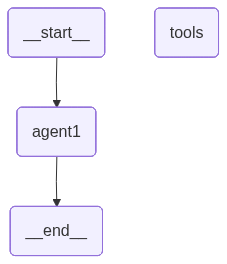

In [74]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Tool calling using ToolNode

In [ ]:
# ✅ REFERENCE SOLUTION — Day 2: ReAct Agent with Conditional Edge
# ─────────────────────────────────────────────────────────────────────────────
# KEY INSIGHTS:
# 1. MessagesState is a pre-built state with a `messages` field that uses
#    add_messages reducer — it APPENDS new messages instead of replacing them.
#    This lets the agent accumulate its conversation history across tool loops.
# 2. The router checks if the last message has `.tool_calls` — if yes, run tools.
# 3. The tools node uses ToolNode — a pre-built LangGraph helper that reads
#    tool_calls from messages and executes the matching @tool function.
# 4. The loop: agent → (conditional) → tools → agent → ... → END
#    Without loops, a ReAct agent is impossible in a plain chain.

from typing import Literal
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.graph.message import MessagesState
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

# ── 1. Define tools ───────────────────────────────────────────────────────────
@tool
def calculator(expression: str) -> str:
    """Evaluates a basic arithmetic expression. Input must be a valid Python math expression."""
    try:
        # Safe eval restricted to math operations
        allowed = {k: v for k, v in __builtins__.items() if k in ("abs", "round", "pow", "min", "max")} if isinstance(__builtins__, dict) else {}
        result = eval(expression, {"__builtins__": allowed})
        return str(result)
    except Exception as e:
        return f"Error: {e}"


@tool
def get_word_count(text: str) -> str:
    """Returns the number of words in the provided text."""
    return str(len(text.split()))


tools = [calculator, get_word_count]

# ── 2. LLM with tools bound ───────────────────────────────────────────────────
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)

# ── 3. Agent node — the LLM decides what to do ───────────────────────────────
def agent_node(state: MessagesState) -> dict:
    """Core reasoning node — LLM picks: call a tool OR produce final answer."""
    print(f"  [agent] Thinking... ({len(state['messages'])} messages in context)")
    response = llm_with_tools.invoke(state["messages"])
    
    if response.tool_calls:
        print(f"  [agent] → decided to call tool: {response.tool_calls[0]['name']}")
    else:
        print(f"  [agent] → producing final answer")
    
    # Return the new AI message — add_messages reducer APPENDS it to the list
    return {"messages": [response]}


# ── 4. Tools node — executes whatever the LLM requested ──────────────────────
# ToolNode is pre-built: reads tool_calls from the last message, runs them,
# returns ToolMessage results that get appended to messages.
tool_node = ToolNode(tools)


# ── 5. Router — conditional edge function ────────────────────────────────────
def should_continue(state: MessagesState) -> Literal["tools", "__end__"]:
    """After the agent runs: if it called a tool → go to tools, else → END."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return END


# ── 6. Build the graph ───────────────────────────────────────────────────────
react_builder = StateGraph(MessagesState)
react_builder.add_node("agent", agent_node)
react_builder.add_node("tools", tool_node)

react_builder.set_entry_point("agent")

# Conditional edge after agent: router decides tools or END
react_builder.add_conditional_edges("agent", should_continue)

# After tools finish, always loop back to agent
react_builder.add_edge("tools", "agent")

react_app = react_builder.compile()


# ── 7. Test it ────────────────────────────────────────────────────────────────
print("=== Test 1: Math question (should use calculator) ===")
result = react_app.invoke({
    "messages": [
        SystemMessage(content="You are a helpful assistant. Use tools when needed."),
        HumanMessage(content="What is 1337 * 42 + 100?")
    ]
})
print(f"\nFinal answer: {result['messages'][-1].content}\n")

print("=== Test 2: General knowledge (should NOT use tools) ===")
result2 = react_app.invoke({
    "messages": [
        HumanMessage(content="What is the capital of France?")
    ]
})
print(f"\nFinal answer: {result2['messages'][-1].content}")


### Getting the raw `ChatVertexAI` for LangGraph (`bind_tools`, `with_structured_output`, etc.)

The `GeminiLangChainLLMAdapter` wraps `ChatVertexAI` behind the `LLMPort` interface
(only `generate_json` is exposed). That's the right boundary for the classifier service,
but for LangGraph you need the raw LangChain object so you can call:

- `llm.bind_tools(tools)` — attach tool schemas for function-calling
- `llm.with_structured_output(schema)` — force a typed output
- pass it directly as a node in a graph

Use `adapter.get_raw_llm()` to retrieve the already-configured `ChatVertexAI` instance.
All proxy, auth, and `api_transport="rest"` fixes are already applied.

In [7]:
# ── Get the raw ChatVertexAI from the adapter ─────────────────────────────────
# All corporate proxy, auth shim, and api_transport="rest" fixes are already
# applied inside the adapter — nothing extra needed here.

from prod.adapters.gcp_auth import GCPAuthManager
from prod.adapters.gemini_langchain_llm import GeminiLangChainLLMAdapter
from prod.config.settings import get_settings

settings = get_settings()
auth     = GCPAuthManager(settings)
adapter  = GeminiLangChainLLMAdapter(settings, auth=auth)

# This is the raw ChatVertexAI — use it anxywhere LangChain/LangGraph expects an LLM
vertex_llm = adapter.get_raw_llm()
print(type(vertex_llm))

# Quick sanity check — plain invoke still works
from langchain_core.messages import HumanMessage, SystemMessage
response = vertex_llm.invoke([HumanMessage(content="Say hello in one word.")])
print("Response:", response.content)

<class 'langchain_google_vertexai.chat_models.ChatVertexAI'>
Response: Hello


In [8]:
# ── bind_tools — for LangGraph tool-calling nodes ────────────────────────────
# Define a tool using the @tool decorator, then bind it to the raw LLM.
# The returned object has the same interface as vertex_llm but with tools attached.

from langchain_core.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    return f"The weather in {city} is sunny and 22°C."

@tool
def get_population(city: str) -> str:
    """Get the population of a city."""
    return f"The population of {city} is approximately 5 million."

# bind_tools tells the model which functions it can call
llm_with_tools = vertex_llm.bind_tools([get_weather, get_population])

# Test it — the model should return a tool_call, not a text answer
response = llm_with_tools.invoke([HumanMessage(content="What is the weather in Sydney?")])
print("tool_calls:", response.tool_calls)
print("content   :", response.content)

tool_calls: [{'name': 'get_weather', 'args': {'city': 'Sydney'}, 'id': 'b4eef494-e9b7-40d8-b3bb-e979f26edf63', 'type': 'tool_call'}]
content   : 


Final answer: The weather in Sydney is sunny and 22°C.


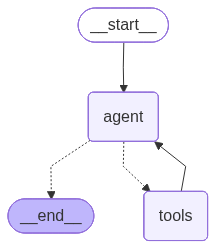

In [9]:
# ── Minimal LangGraph agent using vertex_llm with tools ──────────────────────
# Pattern: one "agent" node (calls LLM), one "tools" node (executes tool calls)
# Conditional edge routes back to agent until no more tool calls.

import json
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import ToolMessage # message type to be appended to the messages state being passed around (content=tool.invoke() , tool_call_id)

class AgentState(TypedDict):
    messages: Annotated[list, add_messages] # add_messages is the inbuilt smart reducer function for the appending of messages state being passed around(also inbuilt in MessagesState)

tools      = [get_weather, get_population]
tools_map  = {t.name: t for t in tools}
agent_llm  = vertex_llm.bind_tools(tools)

def agent_node(state: AgentState) -> dict:
    """Call the LLM — may return tool_calls or a final text answer."""
    response = agent_llm.invoke(state["messages"])
    return {"messages": [response]}

def tools_node(state: AgentState) -> dict:
    """Execute every tool_call from the last AI message."""
    last_msg   = state["messages"][-1]
    tool_results = []
    for tc in last_msg.tool_calls:
        result = tools_map[tc["name"]].invoke(tc["args"])
        tool_results.append(ToolMessage(content=result, tool_call_id=tc["id"]))
    return {"messages": tool_results}

def should_continue(state: AgentState) -> str:                              # conditional edge, router function for the edge, returns name of node to go to ("tools"/END)
    """Route: if last message has tool calls → run tools, else → end."""
    return "tools" if state["messages"][-1].tool_calls else END             # goes to tools, if state's last message has a not None tool_calls object 

builder = StateGraph(AgentState)
builder.add_node("agent", agent_node)
builder.add_node("tools", tools_node)
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END}) # the return dictionary mapping as third param?, router function as 2nd paramm essentially a pseudo node to go to from "agent" node
builder.add_edge("tools", "agent")   # loop back after tool execution
agent_graph = builder.compile()

# Run it
result = agent_graph.invoke({"messages": [HumanMessage(content="What is the weather in Sydney?")]})
print("Final answer:", result["messages"][-1].content)

from IPython.display import Image, display

display(Image(agent_graph.get_graph().draw_mermaid_png()))


#### @tool decorator from langchain.tools / langchain_core.tools

Yes, adding the @tool decorator from langchain_core.tools (or langchain.tools) to a function automatically converts it into a LangChain Tool object, which has an .invoke() method.   
  
The decorator streamlines the creation of tools, handling several steps automatically:   
Encapsulation: It wraps your simple Python function in a structure that adheres to the LangChain Tool Interface.  
Schema Generation: It automatically infers the input schema (using pydantic internally) from the function's type hints and uses the docstring as the tool's description.  
Invokable Interface: The resulting object is a Runnable (the base interface for all executable components in LangChain), which means it automatically gains the standard invocation methods, including .invoke(), .ainvoke() (for asynchronous calls), .batch(), etc.    
You can then use this newly created tool object and its .invoke() method to execute the original function's logic within a LangChain workflow or on its own. 

In [62]:
#for grpc issue, backup solution, needs notebook restart
#! export GRPC_DEFAULT_SSL_ROOTS_FILE_PATH=

I0000 00:00:1772586112.665333 15499474 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: self signed certificate in certificate chain
I0000 00:00:1772586117.669463 15499466 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: self signed certificate in certificate chain
I0000 00:00:1772586117.669463 15499467 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: self signed certificate in certificate chain
I0000 00:00:1772586132.684989 15499467 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: self signed certificate in certificate chain
I0000 00:00:1772586137.687100 15499472 ssl_transport_security.cc:1884] Hands

### ✅ Day 2 Checkpoint

- [ ] You can explain what a conditional edge router function returns  
- [ ] You understand why `tools → agent` creates a loop (not an infinite one — the LLM stops calling tools eventually)  
- [ ] You know what `MessagesState` and `add_messages` give you vs a plain `list`  
- [ ] You can trace a multi-turn tool-calling exchange through the graph by hand  

---

# 📅 Day 3 — Multi-Agent: Supervisor Pattern

**Time budget:** ~30 min concepts + 90 min hands-on  
**LinkedIn Post #1 tonight** — open `02_linkedin_posts.md`

---

## 📖 Must-Read Docs

| Doc | What you'll learn | URL |
|---|---|---|
| Multi-Agent Architectures | Supervisor vs peer-to-peer vs hierarchical | https://langchain-ai.github.io/langgraph/concepts/multi_agent/ |
| How-To: Supervisor | Reference implementation to study | https://langchain-ai.github.io/langgraph/how-tos/multi-agent-network/ |
| Agent Handoffs | How to pass control between agents | https://langchain-ai.github.io/langgraph/how-tos/agent-handoffs/ |

**Minimum read on a lazy day:** Read the Multi-Agent Architectures concepts page. It explains when to use supervisor vs other patterns and why — this is interview-level knowledge.

---

## 🧠 Core Concepts

### Supervisor pattern

```
               ┌──────────────────────────────────┐
               │           SUPERVISOR             │
               │  (LLM decides: who goes next?)   │
               └──────┬──────────────┬────────────┘
                      │              │
               ┌──────▼───┐   ┌──────▼───┐
               │ Research │   │  Writer  │
               │  Agent   │   │  Agent   │
               └──────────┘   └──────────┘
```

- The **supervisor** is just a node (an LLM call) that reads the current messages and decides: call `ResearchAgent`, call `WriterAgent`, or output `FINISH`  
- Worker agents each do ONE thing well  
- The supervisor loops until it decides the task is done  

### Why not just chain them?

Chains assume a fixed order: Research → Write → Done.  
A supervisor can: Research → Research again (got partial info) → Write → Review → Write again.  
That flexibility requires a loop — hence LangGraph.

### How the supervisor decides

The supervisor LLM is prompted with a list of worker names and instructed to always respond with a JSON like `{"next": "ResearchAgent"}` or `{"next": "FINISH"}`. This is structured output routing.

```python
from langchain_core.output_parsers.openai_functions import JsonOutputFunctionsParser
```


### ChatVertexAI multi agent graph

***Known Bugs :***  
- Gemini / Vertex API will only accept user > model > user > model chain
- so compulsory need to append [SystemMessage(), HumanMessage()] at every node/agent call
- cannot have [SystemMessage(), AIMessage(), AIMessage()] as input to model
- so insert HumanMessage at every node   

In [91]:
len(result["messages"])

2

In [6]:
# 🧪 YOUR CODE HERE — Day 3: Supervisor multi-agent system
#
# Build a 3-node system:
# - SupervisorState: messages (with add_messages) + next (str, who to call next)
#
# Nodes:
# - supervisor_node: LLM picks {"next": "ResearchAgent"} or {"next": "WriterAgent"} or {"next": "FINISH"}
# - research_agent_node: given the query in messages, returns a mock research result
# - writer_agent_node: given the research result in messages, drafts a short paragraph
#
# The router after supervisor checks state["next"]:
#   "ResearchAgent" → research_agent_node
#   "WriterAgent"   → writer_agent_node
#   "FINISH"        → END
#
# After worker nodes complete, they always route back to supervisor.
#
# Test with: "Write a short paragraph about the Great Barrier Reef"


from typing import Optional, Literal
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import ToolMessage, HumanMessage, SystemMessage
from langgraph.graph import MessagesState


PROMPTS = {
    "RESEARCH" :  "Conduct thorough research on this query and provide fodder points to be used by the writer agent.", 
    "WRITER" : "Write a brief write-up on the shared query with help of fodder points provided.",
    "SUPERVISOR" : "Look at the output in the state and decide if the next step should be to direct to :\
                    1.ResearchAgent - if the topic needs research or writeup needs improvement.\
                    2.WriterAgent - if the research content seems enough to write on the given topic.\
                    3.FINISH - if previous output by WriterAgent is satisfactory. \
                    Strictly output text content either 'ResearchAgent' OR 'WriterAgent' OR 'FINISH' "
}
# vertex_llm = adapter.get_raw_llm()


class SupervisorState(MessagesState):
    next_call: Optional[str] = None 

from pydantic import BaseModel

class SupervisorOutput(BaseModel):
    next_call: Literal["ResearchAgent", "WriterAgent", "FINISH"]
    

def research_node(state: SupervisorState):
    node_prompt = PROMPTS["RESEARCH"]
    sys_prompt = SystemMessage(content = node_prompt)
    query = state["messages"][0].content                 # always the original human query
    prompt_in = [
        SystemMessage(content=node_prompt),
        HumanMessage(content=query)
    ]
    result = vertex_llm.invoke(prompt_in)
    print("research_node result : =================================== \n", result)
    # print("state : " , state )
    return {"messages" : result } 

def writer_node(state: SupervisorState):
    node_prompt = PROMPTS["WRITER"]
    sys_prompt = SystemMessage(content = node_prompt)
    research_content = state["messages"][-1].content      # extract text from AIMessage
    prompt_in = [
        SystemMessage(content=PROMPTS["WRITER"]),
        HumanMessage(content=f"Use the following research fodder to write:\n\n{research_content}")
    ]
    result = vertex_llm.invoke(prompt_in)
    print("writer_node result : =================================== \n", result)
    # print("state : " , state )
    return {"messages" : result } 

def supervisor_node(state: SupervisorState):
    history = "\n\n".join(
        f"[{m.type.upper()}]: {m.content}"
        for m in state["messages"]
    )
    node_prompt = PROMPTS["SUPERVISOR"]
    prompt_in = [
        SystemMessage(content=node_prompt),
        HumanMessage(content=f"Conversation so far:\n\n{history}\n\nWhat should be the next step?")
    ]
                                                                          # how to pass all conversation to supervisor for reference on performance ? "loop over state, add in HumanMessage"
    #alt_prompt_in=[SystemMessage(content=node_prompt), *state["messages"]] # wont work for Gemini as it would still expect a HumanMessage btwn subsequent agent calls
    supervisor_llm = vertex_llm.with_structured_output(SupervisorOutput) # pass pydantic model
    result = supervisor_llm.invoke(prompt_in)
    print("supervisor_node result : ", result)
    # print("state : " , state )
    return {"next_call" : result.next_call }   # output will follow pydantic object with mentioned keys

def router_edge(state: SupervisorState):
    print('state["next_call"] : ' , state["next_call"])
    if state["next_call"]=="ResearchAgent" :
        return "research_node"
    elif state["next_call"]=="WriterAgent" :
        return "writer_node"
    elif state["next_call"]=="FINISH" :
        return END




In [10]:


builder = StateGraph(SupervisorState)
builder.add_node("research_node", research_node )
builder.add_node("writer_node", writer_node)
builder.add_node("supervisor_node", supervisor_node)
builder.add_edge(START, "supervisor_node")
builder.add_conditional_edges("supervisor_node", router_edge, {"ResearchAgent":"research_node", "WriterAgent":"writer_node", "FINISH":END}) # add the path map dict as third parameter, to ensure it reflects in the png/mermaid diagram of graph
builder.add_edge("research_node", "supervisor_node")
builder.add_edge("writer_node", "supervisor_node")

graph = builder.compile()

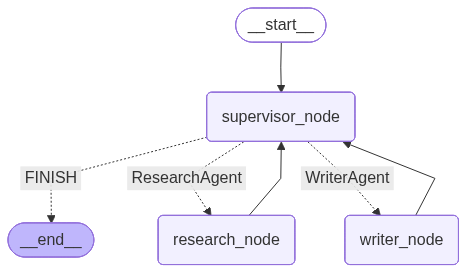

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# go to mlflow cell, to continue with local mlflow logging and wrapping

supervisor_node result :  next_call='ResearchAgent'
state :  {'messages': [HumanMessage(content='Write a short summary on Qubits', additional_kwargs={}, response_metadata={}, id='c800b76c-7ee2-4466-b8c5-ae99e3de59ba')]}
state["next_call"] :  ResearchAgent
research_node result : =================================== 
 content='Here are fodder points for a short summary on Qubits, designed to be comprehensive yet concise for a writer agent:\n\n---\n\n**Qubits: The Building Blocks of Quantum Computing**\n\n**1. Core Definition & Analogy:**\n    *   **What it is:** A "quantum bit" (qubit) is the fundamental unit of quantum information.\n    *   **Analogy:** It\'s the quantum equivalent of a classical computer bit.\n    *   **Classical Bit:** Can only exist in one of two definite states: 0 or 1.\n\n**2. Key Quantum Properties (The "Magic"):**\n    *   **Superposition:**\n        *   Unlike a classical bit, a qubit can exist in a state of 0, 1, or *both simultaneously*.\n        *   Think of i

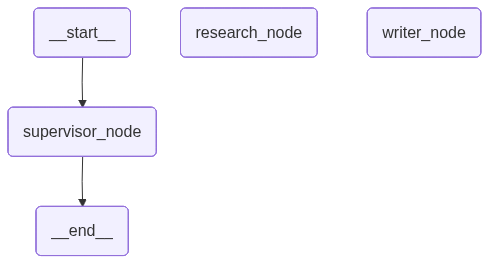

In [106]:
initial_input = {
    "messages" : [HumanMessage(content="Write a short summary on Qubits")]
}

result = graph.invoke(initial_input)

print(result)


#### Caveats and Failsafes for Gemini/Vertex endpoints

**Observe** that the output where AIMessage is following the SystemMessage to go from ResearchAgent to WriterAgent, gemini is appending only one or two tokens as context instead of the entiree content of the ResearchAgent's response.  
**Solution** is to add HumanMessage or use another approach where context bus (research/writing) for API bus is separated from State bus for internode communication. 

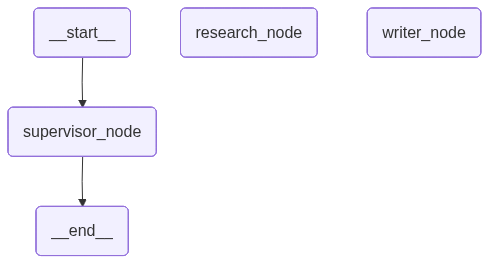

In [103]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
from typing import Union 
def _as_text(msg_content: Union[str, list]) -> str:
    """Safely extract text from AIMessage.content (supports string or content parts)."""
    if isinstance(msg_content, str):
        return msg_content
    if isinstance(msg_content, list):
        for part in msg_content:
            if isinstance(part, dict) and part.get("type") == "text":
                return part.get("text") or part.get("content") or ""
    return ""

# so that the writer node is not confused when gemini returns parts instead of string

def writer_node(state: SupervisorState):
    node_prompt = PROMPTS["WRITER"]
    research_content = _as_text(state["messages"][-1].content)
    prompt_in = [
        SystemMessage(content=PROMPTS["WRITER"]),
        HumanMessage(content=f"Use the following research fodder to write:\n\n{research_content}")
    ]
    result = vertex_llm.invoke(prompt_in)
    print("writer_node result : =================================== \n", result)
    return {"messages": result}




#### simplified routing edge possible with 

```python
# ── Router after supervisor ───────────────────────────────────────────────────  
def supervisor_router(state: SupervisorState) -> str:  
    return state["next"]  
  
# while adding conditional edge, add dictionary mapping output to next node  
supervisor_builder.add_conditional_edges(  
    "supervisor",  
    supervisor_router,  
    {  
        "ResearchAgent": "ResearchAgent",  
        "WriterAgent": "WriterAgent",  
        "FINISH": END,  
    }                                       # this is also called pathmap and gives context to the png mermaid diagram
)  
```  
    

Only fields annotated with reducers (like messages) support partial returns.  
messages : Annotated[List(str), add_messages] 
For non-reducer fields (like your next_call),   
the default behavior is last-write-wins (replacement) and you may need to ensure it exists / is set at least once. Hence set to None in class definition.


#### Logging with ML Flow local

In [1]:
!pip install mlflow

  Using cached werkzeug-3.1.6-py3-none-any.whl.metadata (4.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 363.0 kB/s  0:00:27.2 kB/s eta 0:00:03:09
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 3.8 MB/s  0:00:00m 3.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.8 MB/s  0:00:003.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.0/814.0 kB 4.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 2.2 MB/s  0:00:01m 2.6 MB/s eta 0:00:01
Using cached werkzeug-3.1.6-py3-none-any.whl (225 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30/30 [mlflow]8;5;237m━ 29/30 [mlflow]]metry-sdk]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [26]:
import os
os.environ.pop("MLFLOW_TRACKING_URI", None)
os.environ["MLFLOW_TRACKING_URI"] = "sqlite:///mlflow.db"

import mlflow
import shutil, pathlib

# ── Clean up corrupt mlruns/1 directory (missing meta.yaml) ──────────────────
corrupt_dir = pathlib.Path("./mlruns/1")
if corrupt_dir.exists() and not (corrupt_dir / "meta.yaml").exists():
    shutil.rmtree(corrupt_dir)
    print(f"🗑️  Removed corrupt {corrupt_dir}")

# ── Use SQLite backend (the mlflow.db already written in your last run) ───────
# The filesystem backend (./mlruns) is deprecated Feb 2026 AND is a different
# store from mlflow.db — so the UI showed nothing because it was reading mlruns/
# while the data was in the db. Point both notebook and UI at the same file.
mlflow.set_tracking_uri("sqlite:///mlflow.db")

mlflow.set_experiment("local/langgraph-supervisor-demo")

# Enable autologging: captures traces for LangChain/LangGraph
mlflow.langchain.autolog()

print("✅ Tracking URI:", mlflow.get_tracking_uri())


✅ Tracking URI: sqlite:///mlflow.db


In [28]:
import pathlib, textwrap

# ── Step 1: Write the model-code file ─────────────────────────────────────────
# MLflow ≥ 2.12 requires models-from-code: lc_model must be a .py file path,
# not a live object. The file must call mlflow.models.set_model() at the end.
MODEL_FILE = pathlib.Path("./supervisor_model.py")

MODEL_FILE.write_text(textwrap.dedent('''
    import sys
    from typing import Optional, Literal, Union

    import mlflow
    from langchain_core.messages import HumanMessage, SystemMessage
    from langgraph.graph import StateGraph, MessagesState, START, END
    from pydantic import BaseModel

    mlflow.langchain.autolog()
    # ── LLM setup (same as notebook) ──────────────────────────────────────────
    PROD_ROOT = "/Users/s748779/CEP_AI/anzsic_mapping_v1"
    if PROD_ROOT not in sys.path:
        sys.path.insert(0, PROD_ROOT)

    from prod.adapters.gcp_auth import GCPAuthManager
    from prod.adapters.gemini_langchain_llm import GeminiLangChainLLMAdapter
    from prod.config.settings import get_settings

    settings   = get_settings()
    auth       = GCPAuthManager(settings)
    adapter    = GeminiLangChainLLMAdapter(settings, auth=auth)
    vertex_llm = adapter.get_raw_llm()

    # ── Prompts ────────────────────────────────────────────────────────────────
    PROMPTS = {
        "RESEARCH": (
            "Conduct thorough research on this query and provide fodder points "
            "to be used by the writer agent."
        ),
        "WRITER": (
            "Write a brief write-up on the shared query with help of fodder "
            "points provided."
        ),
        "SUPERVISOR": (
            "Look at the output in the state and decide if the next step should "
            "be to direct to:\\n"
            "  1. ResearchAgent - if the topic needs research or writeup needs improvement.\\n"
            "  2. WriterAgent   - if the research content seems enough to write on the given topic.\\n"
            "  3. FINISH        - if previous output by WriterAgent is satisfactory.\\n"
            "Strictly output text content either 'ResearchAgent' OR 'WriterAgent' OR 'FINISH'."
        ),
    }

    # ── State & structured output ──────────────────────────────────────────────
    class SupervisorState(MessagesState):
        next_call: Optional[str] = None

    class SupervisorOutput(BaseModel):
        next_call: Literal["ResearchAgent", "WriterAgent", "FINISH"]

    # ── Helper ────────────────────────────────────────────────────────────────
    def _as_text(msg_content: Union[str, list]) -> str:
        if isinstance(msg_content, str):
            return msg_content
        if isinstance(msg_content, list):
            for part in msg_content:
                if isinstance(part, dict) and part.get("type") == "text":
                    return part.get("text") or part.get("content") or ""
        return ""

    # ── Nodes ─────────────────────────────────────────────────────────────────
    def research_node(state: SupervisorState):
        query = state["messages"][0].content
        result = vertex_llm.invoke([
            SystemMessage(content=PROMPTS["RESEARCH"]),
            HumanMessage(content=query),
        ])
        return {"messages": result}

    def writer_node(state: SupervisorState):
        research_content = _as_text(state["messages"][-1].content)
        result = vertex_llm.invoke([
            SystemMessage(content=PROMPTS["WRITER"]),
            HumanMessage(content=f"Use the following research fodder to write:\\n\\n{research_content}"),
        ])
        return {"messages": result}

    def supervisor_node(state: SupervisorState):
        history = "\\n\\n".join(
            f"[{m.type.upper()}]: {m.content}" for m in state["messages"]
        )
        supervisor_llm = vertex_llm.with_structured_output(SupervisorOutput)
        result = supervisor_llm.invoke([
            SystemMessage(content=PROMPTS["SUPERVISOR"]),
            HumanMessage(content=f"Conversation so far:\\n\\n{history}\\n\\nWhat should be the next step?"),
        ])
        return {"next_call": result.next_call}

    def router_edge(state: SupervisorState):
        mapping = {
            "ResearchAgent": "research_node",
            "WriterAgent":   "writer_node",
            "FINISH":        END,
        }
        return mapping[state["next_call"]]

    # ── Build graph ───────────────────────────────────────────────────────────
    builder = StateGraph(SupervisorState)
    builder.add_node("research_node",  research_node)
    builder.add_node("writer_node",    writer_node)
    builder.add_node("supervisor_node", supervisor_node)
    builder.add_edge(START, "supervisor_node")
    builder.add_conditional_edges("supervisor_node", router_edge)
    builder.add_edge("research_node", "supervisor_node")
    builder.add_edge("writer_node",   "supervisor_node")
    graph = builder.compile()

    # ── Required by MLflow models-from-code ───────────────────────────────────
    mlflow.models.set_model(graph)
''').lstrip())

print(f"✅ Written: {MODEL_FILE.resolve()}")

# ── Step 2: Log via models-from-code ──────────────────────────────────────────
with mlflow.start_run():
    logged = mlflow.langchain.log_model(
        lc_model=str(MODEL_FILE),                   # <-- path, not object
        artifact_path="langgraph_supervisor_agent",
        input_example={"messages": [{"type": "human", "content": "Write a short summary on Atom Arrays"}]},
        pip_requirements=[
            "mlflow",
            "langgraph",
            "langchain-core",
            "langchain-google-vertexai",
        ],
    )

print("Model URI:", logged.model_uri)


2026/03/06 11:11:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/06 11:11:09 WARNING mlflow.tracing.fluent: Failed to start span LangGraph: 'NonRecordingSpan' object has no attribute 'context'. For full traceback, set logging level to debug.


✅ Written: /Users/s748779/learnings /li_blog/practice/supervisor_model.py


2026/03/06 11:12:10 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-8f51a0911c44487bb191376ffdcbdfa4
2026/03/06 11:12:10 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
2026/03/06 11:12:10 WARNING mlflow.tracing.fluent: Failed to start span LangGraph: 'NonRecordingSpan' object has no attribute 'context'. For full traceback, set logging level to debug.


Model URI: models:/m-8f51a0911c44487bb191376ffdcbdfa4


In [29]:

loaded = mlflow.pyfunc.load_model(logged.model_uri)

# The PyFunc wrapper expects a list of requests; supply one chat-like payload
payload = [{"messages": [
    {"type":"human", "content":"Write a short summary on Qubits"}
]}]

out = loaded.predict(payload)
print(out)


[{'messages': [{'content': 'Write a short summary on Qubits', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': 'fbd221ec-a823-4ea7-a888-86f922bf3b87'}, {'content': 'Here\'s a summary of Qubits, broken down into fodder points for a writer agent:\n\n---\n\n## Qubits: The Building Blocks of Quantum Computing\n\n**Core Concept & Definition:**\n\n*   **Fundamental Unit:** A qubit (quantum bit) is the basic unit of quantum information, analogous to the classical bit in traditional computing.\n*   **Beyond Binary:** Unlike a classical bit which can only be in one of two states (0 or 1) at any given time, a qubit can exist in a superposition of both 0 and 1 simultaneously.\n\n**Key Quantum Properties:**\n\n1.  **Superposition:**\n    *   **Definition:** The ability of a qubit to be in a combination of multiple states (0 and 1) at the same time.\n    *   **Analogy:** Imagine a spinning coin that is neither heads nor tails until it lands. A qubit is like tha

In [ ]:
loaded = mlflow.pyfunc.load_model(logged.model_uri)

# The PyFunc wrapper expects a list of requests; supply one chat-like payload
payload = [{"messages": [
    {"type":"human", "content":"Write a short summary on Qubits"}
]}]

out = loaded.predict(payload)
print(out)

In [ ]:
# Must point the UI at the same SQLite backend — otherwise it reads ./mlruns
# and shows nothing
!mlflow ui --backend-store-uri sqlite:///mlflow.db


Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
INFO:     Uvicorn running on http://127.0.0.1:5000 (Press CTRL+C to quit)
INFO:     Started parent process [44668]
2026/03/06 11:18:06 INFO mlflow.server.jobs.utils: Starting huey consumer for job function invoke_scorer
2026/03/06 11:18:06 INFO mlflow.server.jobs.utils: Starting huey consumer for job function run_online_trace_scorer
2026/03/06 11:18:06 INFO mlflow.server.jobs.utils: Starting huey consumer for job function optimize_prompts
2026/03/06 11:18:06 INFO mlflow.server.jobs.utils: Starting huey consumer for job function run_online_session_scorer
2026/03/06 11:18:06 INFO mlflow.server.jobs.utils: Starting dedicated Huey consumer for periodic tasks
INFO:     Started server process [44700]
INFO:     Waiting for application startup.
IN

open http://127.0.0.1:5000, navigate to your experiment, and check the Traces tab to see your LangGraph run structure and token usage

#### Adapter Runnable to have same input dict for mlflow loaded predict and graph invoke

for preserving
payload = [{"messages": [
    {"type":"human", "content":"Write a short summary on Qubits"}
]}]

for both type of invokation.


```python
from typing import Dict, List
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langchain_core.runnables import RunnableLambda

TYPE_TO_MSG = {
    "human": HumanMessage,
    "system": SystemMessage,
    "ai": AIMessage,
    "assistant": AIMessage,  # alias if you use 'assistant'
    "tool": ToolMessage,
}

def _to_lc_messages(msg_dicts: List[Dict]):
    msgs = []
    for d in msg_dicts:
        t = (d.get("type") or d.get("role") or "").lower()
        cls = TYPE_TO_MSG.get(t, HumanMessage)  # default to human if unknown
        # ToolMessage requires tool_call_id; if absent, fall back to AI/Human
        if cls is ToolMessage and "tool_call_id" not in d:
            cls = AIMessage
        msgs.append(cls(content=d.get("content", "")))
    return msgs

def adapt_and_invoke(payload: Dict):
    # payload like {"messages": [{"type":"human","content":"..."}]}
    msgs = _to_lc_messages(payload["messages"])
    result_state = graph.invoke({"messages": msgs})
    # result_state is a dict with "messages":[...]; return the last AI text
    last = result_state["messages"][-1]
    text = last.content if isinstance(last.content, str) else (
        next((p.get("text") or p.get("content") for p in last.content if isinstance(p, dict)), "")
        if isinstance(last.content, list) else ""
    )
    return {"output": text}

adapter = RunnableLambda(adapt_and_invoke)
```


### OpenAI based multi turn agents 

In [ ]:
# ✅ REFERENCE SOLUTION — Day 3: Supervisor Multi-Agent System
# ─────────────────────────────────────────────────────────────────────────────
# KEY INSIGHTS:
# 1. The supervisor uses structured output (with_structured_output) to always
#    return a clean {"next": "WorkerName"} decision — no parsing fragility.
# 2. Worker agents are just nodes. They don't need to know about each other.
# 3. After each worker runs, we always go back to the supervisor — the supervisor
#    decides if we need more work or if we're done (FINISH).
# 4. The "next" field in state is set by the supervisor and read by the router.
#    It's a clean pattern: state carries the routing decision.

from typing import TypedDict, Annotated, Literal
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from pydantic import BaseModel

# ── State ─────────────────────────────────────────────────────────────────────
class SupervisorState(TypedDict):
    messages: Annotated[list, add_messages]  # full conversation history
    next: str                                # which worker to call next (set by supervisor)


# ── Structured output for supervisor decision ─────────────────────────────────
class RouteDecision(BaseModel):
    next: Literal["ResearchAgent", "WriterAgent", "FINISH"]


# ── LLM setup ────────────────────────────────────────────────────────────────
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
supervisor_llm = llm.with_structured_output(RouteDecision)


# ── Supervisor node ──────────────────────────────────────────────────────────
SUPERVISOR_SYSTEM = """You orchestrate a team of agents to complete writing tasks.

Workers available:
- ResearchAgent: gathers facts and key information about the topic
- WriterAgent: writes polished prose given gathered research

Rules:
1. Always start by calling ResearchAgent to gather information.
2. After research is complete, call WriterAgent to produce the final output.
3. After WriterAgent produces output, return FINISH.
4. Never loop more than once through each worker.
"""

def supervisor_node(state: SupervisorState) -> dict:
    print(f"\n  [Supervisor] Deciding next step... ({len(state['messages'])} messages)")
    decision = supervisor_llm.invoke([
        SystemMessage(content=SUPERVISOR_SYSTEM),
        *state["messages"]
    ])
    print(f"  [Supervisor] → {decision.next}")
    return {"next": decision.next}


# ── Research agent node ───────────────────────────────────────────────────────
def research_agent_node(state: SupervisorState) -> dict:
    """Gathers information about the topic by calling the LLM as a researcher."""
    print("  [ResearchAgent] Researching...")
    research_prompt = f"""You are a research assistant. 
Gather the 3 most important facts about the topic from the last human message.
Return bullet points only. Be concise and factual."""
    
    response = llm.invoke([
        SystemMessage(content=research_prompt),
        *state["messages"]
    ])
    print(f"  [ResearchAgent] Done — {len(response.content)} chars")
    return {"messages": [AIMessage(content=f"[Research]\n{response.content}", name="ResearchAgent")]}


# ── Writer agent node ─────────────────────────────────────────────────────────
def writer_agent_node(state: SupervisorState) -> dict:
    """Writes a polished paragraph using the research gathered so far."""
    print("  [WriterAgent] Writing...")
    write_prompt = """You are a professional writer.
Using the research notes in the conversation, write a single polished paragraph (3-5 sentences)
that covers the key points naturally and engagingly."""
    
    response = llm.invoke([
        SystemMessage(content=write_prompt),
        *state["messages"]
    ])
    print(f"  [WriterAgent] Done — {len(response.content)} chars")
    return {"messages": [AIMessage(content=f"[Draft]\n{response.content}", name="WriterAgent")]}


# ── Router after supervisor ───────────────────────────────────────────────────
def supervisor_router(state: SupervisorState) -> str:
    return state["next"]


# ── Build the graph ───────────────────────────────────────────────────────────
supervisor_builder = StateGraph(SupervisorState)
supervisor_builder.add_node("supervisor", supervisor_node)
supervisor_builder.add_node("ResearchAgent", research_agent_node)
supervisor_builder.add_node("WriterAgent", writer_agent_node)

supervisor_builder.set_entry_point("supervisor")

supervisor_builder.add_conditional_edges(
    "supervisor",
    supervisor_router,
    {
        "ResearchAgent": "ResearchAgent",
        "WriterAgent": "WriterAgent",
        "FINISH": END,
    }
)

# Workers always return to supervisor after finishing
supervisor_builder.add_edge("ResearchAgent", "supervisor")
supervisor_builder.add_edge("WriterAgent", "supervisor")

supervisor_app = supervisor_builder.compile()


# ── Test it ───────────────────────────────────────────────────────────────────
print("=== Supervisor multi-agent test ===\n")
result = supervisor_app.invoke({
    "messages": [HumanMessage(content="Write a short paragraph about the Great Barrier Reef.")],
    "next": ""
})

print("\n=== FINAL OUTPUT ===")
for msg in result["messages"]:
    name = getattr(msg, "name", type(msg).__name__)
    print(f"\n[{name}]:\n{msg.content}")


### ✅ Day 3 Checkpoint

- [ ] You can explain the supervisor pattern and when you'd choose it over a chain  
- [ ] You understand why `add_messages` is critical when building multi-turn agents  
- [ ] You can trace how `state["next"]` flows from supervisor → router → worker → supervisor  
- [ ] You know why `with_structured_output` makes supervisor routing more reliable than string parsing  

---

# 📅 Day 4 — Memory, Persistence & Human-in-the-Loop

**Time budget:** ~30 min concepts + 90 min hands-on

---

## 📖 Must-Read Docs

| Doc | What you'll learn | URL |
|---|---|---|
| Persistence concepts | How checkpointers work under the hood | https://langchain-ai.github.io/langgraph/concepts/persistence/ |
| MemorySaver | In-memory checkpointer for dev/testing | https://langchain-ai.github.io/langgraph/how-tos/persistence/ |
| SqliteSaver | File-based persistence for local prod | https://langchain-ai.github.io/langgraph/how-tos/persistence/#using-sqlitesaver |
| Human-in-the-Loop | interrupt_before, resume, and approval patterns | https://langchain-ai.github.io/langgraph/concepts/human_in_the_loop/ |

**Minimum read on a lazy day:** Read the Persistence concepts page and the Human-in-the-Loop concepts page. These are architecture-level concepts that come up in interviews for senior agentic roles.

---

## 🧠 Core Concepts

### Two types of memory

| Type | Scope | How | Cleared when |
|---|---|---|---|
| Short-term (in-run) | One graph invocation | State object | Graph finishes |
| Long-term (cross-run) | Multiple invocations | Checkpointer | You decide |

### Checkpointers and thread IDs

A **checkpointer** is a storage backend that snapshots state after every node.  
A **thread_id** is the identifier that groups runs into a "conversation".

```python
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
app = graph.compile(checkpointer=checkpointer)

# Config tells the checkpointer which thread to load/save
config = {"configurable": {"thread_id": "user-123-session-1"}}

# First run: state is saved under thread_id
result1 = app.invoke({"messages": [HumanMessage("Hello")]}, config=config)

# Second run — state is LOADED from checkpointer before running
result2 = app.invoke({"messages": [HumanMessage("What did I just say?")]}, config=config)
# The agent now has context from the first run
```

### Human-in-the-Loop (HITL)

`interrupt_before=["node_name"]` — the graph **pauses** before that node runs.  
You can then inspect the state, modify it, and resume.

```python
app = graph.compile(
    checkpointer=checkpointer,
    interrupt_before=["action_node"]   # pause here
)

# Run until the interrupt
app.invoke(input, config)

# Inspect current state
current = app.get_state(config)
print(current.values)

# Resume (no new input needed — just invoke again with same config)
app.invoke(None, config)
```


In [ ]:
# 🧪 YOUR CODE HERE — Day 4a: Add MemorySaver to the supervisor graph
#
# Steps:
# 1. Import MemorySaver from langgraph.checkpoint.memory
# 2. Re-compile supervisor_app with checkpointer=MemorySaver()
# 3. Create a config with thread_id = "test-thread-1"
# 4. Run the graph with a query — print the final messages
# 5. Run it AGAIN with the SAME thread_id but a NEW message asking a follow-up
# 6. Verify the agent remembers the context from the first run
#    (it should reference the Great Barrier Reef without you mentioning it again)


In [ ]:
# ✅ REFERENCE SOLUTION — Day 4a: MemorySaver — Cross-run Persistence
# ─────────────────────────────────────────────────────────────────────────────
# KEY INSIGHTS:
# 1. MemorySaver stores checkpoints IN MEMORY — it resets when the kernel restarts.
#    It's perfect for development and testing, NOT for production.
# 2. ALL runs with the same thread_id share state — messages accumulate.
# 3. The `config` dict is passed to EVERY invoke/stream call — it's how LangGraph
#    knows which thread's state to load.

from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# Re-compile the supervisor graph WITH a checkpointer
persistent_app = supervisor_builder.compile(checkpointer=memory)

# Thread config — this is the "session ID" for this conversation
config = {"configurable": {"thread_id": "session-reef-demo"}}

print("=== Run 1: Initial query ===")
result1 = persistent_app.invoke(
    {"messages": [HumanMessage("Write a paragraph about the Great Barrier Reef.")], "next": ""},
    config=config
)
print("Run 1 complete.\n")

print("=== Run 2: Follow-up with SAME thread_id ===")
result2 = persistent_app.invoke(
    {"messages": [HumanMessage("Now make it shorter — just 2 sentences.")], "next": ""},
    config=config
)

print("\n=== Final messages in thread ===")
for msg in result2["messages"]:
    name = getattr(msg, "name", type(msg).__name__)
    print(f"[{name}]: {msg.content[:120]}...")

# Inspect state directly — useful for debugging
state_snapshot = persistent_app.get_state(config)
print(f"\nTotal messages in thread: {len(state_snapshot.values['messages'])}")
print(f"Next node (if any): {state_snapshot.next}")


In [ ]:
# ✅ Day 4b: SqliteSaver — File-Based Persistence (survives kernel restarts)
# ─────────────────────────────────────────────────────────────────────────────
# KEY INSIGHTS:
# 1. SqliteSaver writes to a .db file — state survives kernel restarts.
# 2. In production you'd swap this for a Postgres checkpointer.
# 3. The API is identical to MemorySaver — just swap the checkpointer.
# 4. You can inspect the database file directly with a SQLite browser to see
#    exactly what LangGraph is storing (serialised state as JSON blobs).

# Install if needed: pip install langgraph-checkpoint-sqlite
from langgraph.checkpoint.sqlite import SqliteSaver
import pathlib

db_path = pathlib.Path("./langgraph_checkpoints.db")
print(f"Checkpoint DB will be at: {db_path.resolve()}")

with SqliteSaver.from_conn_string(str(db_path)) as sqlite_memory:
    sqlite_app = supervisor_builder.compile(checkpointer=sqlite_memory)

    sqlite_config = {"configurable": {"thread_id": "sqlite-test-1"}}

    result = sqlite_app.invoke(
        {"messages": [HumanMessage("Write a paragraph about Uluru.")], "next": ""},
        config=sqlite_config
    )

    print(f"\nDone. DB file size: {db_path.stat().st_size} bytes")
    print("Open langgraph_checkpoints.db in DB Browser for SQLite to inspect the stored state.")
    print("\nFinal answer:")
    print(result["messages"][-1].content)


In [ ]:
# 🧪 YOUR CODE HERE — Day 4c: Human-in-the-Loop Interrupt
# 
# Steps:
# 1. Re-compile supervisor_builder with:
#    - checkpointer = MemorySaver()  
#    - interrupt_before = ["WriterAgent"]  (pause before writing, let human approve research)
# 2. Thread config: thread_id = "hitl-test-1"
# 3. First invoke: run the graph — it will STOP before WriterAgent runs
# 4. Call app.get_state(config) — print the current messages to see what research was gathered
# 5. Decide: approve (resume) or modify state (update a message) then resume
# 6. Resume by calling app.invoke(None, config) — it picks up where it left off
# 7. Print the final output


In [ ]:
# ✅ REFERENCE SOLUTION — Day 4c: Human-in-the-Loop (HITL) Interrupt
# ─────────────────────────────────────────────────────────────────────────────
# KEY INSIGHTS:
# 1. interrupt_before=["WriterAgent"] pauses execution BEFORE that node runs.
#    The graph saves its state to the checkpointer and returns to you.
# 2. state_snapshot.next tells you which node(s) are waiting to run.
# 3. To resume: call app.invoke(None, config) — None means "no new input, just continue".
# 4. To modify state before resuming: call app.update_state(config, new_values).
#    This is how you inject human feedback into the agent pipeline.
# 5. This pattern is what "human approval" gates look like in production agentic systems.

from langgraph.checkpoint.memory import MemorySaver

hitl_memory = MemorySaver()
hitl_app = supervisor_builder.compile(
    checkpointer=hitl_memory,
    interrupt_before=["WriterAgent"]  # pause here for human review
)

hitl_config = {"configurable": {"thread_id": "hitl-demo-1"}}

print("=== Step 1: Run graph — will pause before WriterAgent ===\n")
hitl_app.invoke(
    {"messages": [HumanMessage("Write a paragraph about the Sydney Opera House.")], "next": ""},
    config=hitl_config
)

# Inspect the paused state
state_snapshot = hitl_app.get_state(hitl_config)
print("=== Paused. Current state: ===")
print(f"Next node(s) waiting: {state_snapshot.next}")
print("\nMessages so far:")
for msg in state_snapshot.values["messages"]:
    name = getattr(msg, "name", type(msg).__name__)
    print(f"  [{name}]: {msg.content[:200]}")

print("\n=== Step 2: Human decision — approve and resume ===")
print("(In a real app, you'd show this to a user and wait for input.)")
print("Resuming automatically...\n")

# Resume with no new input — continue from the paused checkpoint
final_result = hitl_app.invoke(None, config=hitl_config)

print("=== Final Output After Resume ===")
print(final_result["messages"][-1].content)


### ✅ Day 4 Checkpoint

- [ ] You understand the difference between short-term state and long-term checkpointed state  
- [ ] You can explain what `thread_id` does and why two different `thread_id`s don't share state  
- [ ] You know when to use `MemorySaver` (dev) vs `SqliteSaver` (local prod) vs Postgres (cloud)  
- [ ] You can walk through the HITL flow: invoke → pause → inspect → resume  
- [ ] You know what `app.get_state(config)` returns and what `.next` tells you  

---

# 📅 Day 5 — Deploy: LangGraph Agent on AWS

**Time budget:** ~20 min concepts + 100 min hands-on  
**LinkedIn Post #2 tonight** — open `02_linkedin_posts.md`

---

## 📖 Must-Read Docs

| Doc | What you'll learn | URL |
|---|---|---|
| LangGraph + FastAPI patterns | How to expose graphs via REST | https://langchain-ai.github.io/langgraph/tutorials/deployment/ |
| Streaming over HTTP (SSE) | `astream_events` + Server-Sent Events | https://langchain-ai.github.io/langgraph/how-tos/streaming-events-from-within-tools/ |
| FastAPI StreamingResponse | FastAPI's async streaming docs | https://fastapi.tiangolo.com/advanced/custom-response/#streamingresponse |

**Minimum read on a lazy day:** Read the Streaming over HTTP section. Understanding `astream_events` and what event types it yields is crucial for Day 14's full async refactor.

---

## 🧠 Core Concepts

### Options for serving a LangGraph agent

| Option | When to use | Complexity |
|---|---|---|
| **FastAPI wrapper (self-hosted)** | Full control, existing AWS infra | Low–Medium |
| LangGraph Cloud | Managed hosting, team collaboration | Low (opinionated) |
| Lambda + API Gateway | Low-traffic, bursty workloads | Medium–High |
| ECS/Fargate | Production-scale, auto-scaling | Medium |

**Day 5 focus: FastAPI + Docker + EC2** — this is the most transferable setup.

### Two endpoints you need

1. **POST /invoke** — synchronous, returns the full final state as JSON  
2. **GET /stream** — async SSE, streams state updates as the graph runs  

### SSE (Server-Sent Events)

SSE is how you push data from server to client progressively:
```
data: {"node": "call_llm", "content": "The capital..."}

data: {"node": "format_output", "content": "Answer: The capital..."}

data: [DONE]
```

FastAPI's `StreamingResponse` with `media_type="text/event-stream"` handles this.

### `astream_events` — the right streaming API for production

Don't use `.stream()` (yields full node outputs) for user-facing UIs.  
Use `.astream_events(input, version="v2")` — it yields fine-grained events including **individual tokens** as the LLM generates them.

### 🧪 Try It Yourself — 5.1: Build the FastAPI wrapper

Before looking at the reference solution, try to write `app/main.py` with:

1. A `POST /invoke` endpoint that:
   - Accepts `{"query": "...", "thread_id": "..."}` as a JSON body (`BaseModel`)
   - Calls the supervisor agent with `invoke()`
   - Returns `{"response": "...", "messages_count": N}`

2. A `GET /stream` endpoint that:
   - Accepts `query` and `thread_id` as query params
   - Calls `astream_events()` on the async version of the graph
   - Streams events as SSE: `data: {json}\n\n`
   - Ends with `data: [DONE]\n\n`

**Key pattern to know:**
```python
from fastapi.responses import StreamingResponse

async def event_generator():
    async for event in graph.astream_events(input, version="v2"):
        if event["event"] == "on_chat_model_stream":
            yield f"data: {event['data']['chunk'].content}\n\n"
    yield "data: [DONE]\n\n"

return StreamingResponse(event_generator(), media_type="text/event-stream")
```

In [ ]:
# ✅ REFERENCE SOLUTION — Day 5.1: FastAPI wrapper (write this to app/main.py)
# ─────────────────────────────────────────────────────────────────────────────
# This cell shows you the FULL content of main.py.
# In practice: create app/main.py in your project and paste this there.
# You can run it from terminal: uvicorn app.main:app --reload
#
# KEY INSIGHTS:
# 1. Both endpoints accept thread_id so the caller controls conversation continuity.
# 2. /invoke is sync (uses .invoke()) — fine for short-running graphs.
# 3. /stream is async (uses .astream_events()) — yields tokens as they arrive.
# 4. on_chat_model_stream events carry individual LLM tokens — perfect for UIs.
# 5. We use a MemorySaver here; swap for SqliteSaver or Postgres in real prod.

FASTAPI_MAIN_PY = '''
# app/main.py
import json
import os
from typing import Annotated

from fastapi import FastAPI, Query
from fastapi.responses import StreamingResponse
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel

# ── Import your compiled graph ────────────────────────────────────────────────
# In your project structure, the graph lives in app/agent.py (export supervisor_builder)
# For this demo we reference the objects built earlier in the notebook.
# In a real app:  from app.agent import supervisor_builder

# ── App setup ─────────────────────────────────────────────────────────────────
app = FastAPI(title="LangGraph Agent API", version="1.0.0")

# Single in-memory checkpointer shared across requests
# In production: use a thread-safe Postgres or Redis checkpointer
_memory = MemorySaver()
_agent = supervisor_builder.compile(checkpointer=_memory)


# ── Request models ─────────────────────────────────────────────────────────────
class InvokeRequest(BaseModel):
    query: str
    thread_id: str = "default"


# ── POST /invoke — synchronous, returns full response ─────────────────────────
@app.post("/invoke")
async def invoke_agent(request: InvokeRequest):
    config = {"configurable": {"thread_id": request.thread_id}}
    result = _agent.invoke(
        {"messages": [HumanMessage(content=request.query)], "next": ""},
        config=config
    )
    last_message = result["messages"][-1].content
    return {
        "response": last_message,
        "thread_id": request.thread_id,
        "messages_count": len(result["messages"])
    }


# ── GET /stream — async SSE, streams tokens as the LLM generates them ─────────
@app.get("/stream")
async def stream_agent(
    query: Annotated[str, Query(description="User query")],
    thread_id: Annotated[str, Query(description="Conversation thread ID")] = "default"
):
    config = {"configurable": {"thread_id": thread_id}}

    async def event_generator():
        try:
            async for event in _agent.astream_events(
                {"messages": [HumanMessage(content=query)], "next": ""},
                config=config,
                version="v2"
            ):
                event_type = event["event"]

                # Stream individual LLM tokens as they arrive
                if event_type == "on_chat_model_stream":
                    chunk = event["data"]["chunk"].content
                    if chunk:
                        payload = json.dumps({"type": "token", "content": chunk})
                        yield f"data: {payload}\\n\\n"

                # Announce when a node starts running
                elif event_type == "on_chain_start" and event.get("name") in ("supervisor", "ResearchAgent", "WriterAgent"):
                    payload = json.dumps({"type": "node_start", "node": event["name"]})
                    yield f"data: {payload}\\n\\n"

        except Exception as e:
            payload = json.dumps({"type": "error", "message": str(e)})
            yield f"data: {payload}\\n\\n"
        finally:
            yield "data: [DONE]\\n\\n"

    return StreamingResponse(event_generator(), media_type="text/event-stream")


# ── Health check ───────────────────────────────────────────────────────────────
@app.get("/health")
async def health():
    return {"status": "ok"}
'''

print("=== app/main.py content ===")
print(FASTAPI_MAIN_PY)

# Write the file to disk so you can run it immediately
import pathlib
app_dir = pathlib.Path("./app")
app_dir.mkdir(exist_ok=True)
(app_dir / "__init__.py").touch()
(app_dir / "main.py").write_text(FASTAPI_MAIN_PY.strip())
print(f"\n✅ Written to: {(app_dir / 'main.py').resolve()}")
print("Run with: uvicorn app.main:app --reload --port 8000")


In [ ]:
# ✅ Day 5.2: Dockerfile — Containerise the FastAPI app
# ─────────────────────────────────────────────────────────────────────────────
# KEY INSIGHTS:
# 1. We use a slim Python base — ml-specific images are too large for an API server.
# 2. requirements.txt lives alongside Dockerfile (one level above app/).
# 3. OPENAI_API_KEY is passed at runtime (docker run -e) — NEVER baked into the image.
# 4. Expose 8000 is documentation only — you still need -p 8000:8000 in docker run.
# 5. --workers 1 keeps it simple; for prod scale, use Gunicorn with multiple Uvicorn workers.

DOCKERFILE_CONTENT = """# Dockerfile
FROM python:3.11-slim

WORKDIR /code

# Install dependencies first (Docker layer cache — rebuilds only when requirements change)
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy application code
COPY app/ ./app/

# Expose the port FastAPI runs on
EXPOSE 8000

# Run with uvicorn
CMD ["uvicorn", "app.main:app", "--host", "0.0.0.0", "--port", "8000", "--workers", "1"]
"""

REQUIREMENTS_TXT = """fastapi>=0.110.0
uvicorn[standard]>=0.27.0
langgraph>=0.2.0
langchain-openai>=0.1.0
langchain-community>=0.2.0
langgraph-checkpoint-sqlite>=1.0.0
pydantic>=2.0.0
python-dotenv>=1.0.0
"""

import pathlib
pathlib.Path("./Dockerfile").write_text(DOCKERFILE_CONTENT.strip())
pathlib.Path("./requirements.txt").write_text(REQUIREMENTS_TXT.strip())

print("✅ Dockerfile written")
print("✅ requirements.txt written")
print()
print("=== To build and run locally: ===")
print("  docker build -t langgraph-agent .")
print("  docker run -p 8000:8000 -e OPENAI_API_KEY=$OPENAI_API_KEY langgraph-agent")
print()
print("=== Test the running container: ===")
print('  curl -X POST http://localhost:8000/invoke \\')
print('    -H "Content-Type: application/json" \\')
print('    -d \'{"query": "Write a short paragraph about Bondi Beach", "thread_id": "test-1"}\'')
print()
print('  # Streaming:')
print('  curl -N "http://localhost:8000/stream?query=Tell+me+about+Australia&thread_id=test-2"')


### 🚀 Day 5.3: Deploy to AWS EC2 via ECR

**These steps run in your terminal — not in the notebook.**

---

#### Step 1: Authenticate Docker to ECR

```bash
AWS_ACCOUNT_ID=$(aws sts get-caller-identity --query Account --output text)
AWS_REGION=ap-southeast-2  # Sydney
ECR_REPO=langgraph-agent

# Create the ECR repository (one-time)
aws ecr create-repository --repository-name $ECR_REPO --region $AWS_REGION

# Authenticate Docker to ECR
aws ecr get-login-password --region $AWS_REGION | \
  docker login --username AWS --password-stdin $AWS_ACCOUNT_ID.dkr.ecr.$AWS_REGION.amazonaws.com
```

---

#### Step 2: Build, tag, and push the image

```bash
ECR_URI=$AWS_ACCOUNT_ID.dkr.ecr.$AWS_REGION.amazonaws.com/$ECR_REPO

docker build -t $ECR_REPO .
docker tag $ECR_REPO:latest $ECR_URI:latest
docker push $ECR_URI:latest

echo "Pushed to: $ECR_URI:latest"
```

---

#### Step 3: Launch an EC2 instance and run the container

```bash
# SSH into your EC2 instance (Amazon Linux 2 or Ubuntu)
# Ensure the instance has an IAM role with ECR pull permissions

# On the EC2 instance:
sudo yum install -y docker
sudo service docker start
sudo usermod -a -G docker ec2-user

# Authenticate from EC2 to ECR (the IAM role handles credentials)
aws ecr get-login-password --region ap-southeast-2 | \
  docker login --username AWS --password-stdin $AWS_ACCOUNT_ID.dkr.ecr.$AWS_REGION.amazonaws.com

# Pull and run
docker pull $ECR_URI:latest
docker run -d \
  -p 8000:8000 \
  -e OPENAI_API_KEY="$OPENAI_API_KEY" \
  --name langgraph-agent \
  --restart unless-stopped \
  $ECR_URI:latest

echo "Agent running at http://$(curl -s ifconfig.me):8000"
```

---

#### Step 4: Test the deployed endpoint

```bash
EC2_IP=<your-ec2-public-ip>

# Test invoke
curl -X POST http://$EC2_IP:8000/invoke \
  -H "Content-Type: application/json" \
  -d '{"query": "Write a paragraph about Bondi Beach", "thread_id": "prod-test-1"}'

# Test streaming
curl -N "http://$EC2_IP:8000/stream?query=Tell+me+about+Australia&thread_id=prod-test-2"

# Health check
curl http://$EC2_IP:8000/health
```

---

#### EC2 Security Group (minimum required)
- **Inbound:** TCP port 8000 from your IP (for testing), or 0.0.0.0/0 if making it public  
- **Inbound:** TCP port 22 from your IP (for SSH)  
- **Outbound:** All traffic (for ECR pull + OpenAI API calls)

---

> **Production upgrade path:** Replace EC2 with ECS/Fargate + ALB for auto-scaling.  
> Replace MemorySaver with a Postgres checkpointer (RDS) for durable state across restarts.

### ✅ Day 5 Checkpoint

- [ ] You can explain the two endpoints (`/invoke` vs `/stream`) and when to use each  
- [ ] You understand what SSE is and how `StreamingResponse` + `astream_events` produces it  
- [ ] You can trace the Docker build → ECR push → EC2 pull → run flow  
- [ ] You know why API keys go in environment variables, never in the image  
- [ ] You can test both endpoints with `curl` from a terminal  

---

# 🏆 Days 1–5 Complete: What You Now Have

| Deliverable | Demonstrated Skills |
|---|---|
| 2-node StateGraph (invoke + stream) | Core LangGraph primitives, state management |
| ReAct agent with tools + conditional routing | Tool calling, conditional edges, loops |
| 3-agent supervisor system | Multi-agent orchestration, structured output routing |
| Persistent agent with HITL interrupt | MemorySaver, SqliteSaver, human-in-the-loop patterns |
| FastAPI app (sync + SSE streaming) | Production API design, streaming with `astream_events` |
| Dockerfile + ECR + EC2 deploy guide | Containerisation, Docker, AWS deployment |

---

## 🔗 Next: Days 6–10 — LLM Evaluation / LLMOps

Open `Code_Along_Day_6_10.ipynb` (coming next) to cover:
- RAGAS evaluation on real RAG pipelines
- Custom LLM-as-a-judge evaluator
- LangSmith tracing + observability
- Guardrails AI integration
- GitHub Actions CI/CD eval pipeline

**LinkedIn Post #2** is due tonight — open `docs/02_linkedin_posts.md`.
